In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
path = "/content/drive/MyDrive/Project_Machine_Learning/Praktikum_10/Data/"

df = pd.read_excel(path + "Grade.xlsx")

In [31]:
df

,NIM,Hasil Sebenarnya,Hasil Prediksi
0,TI001,Lulus,Lulus
1,TI002,Lulus,Lulus
2,TI003,Lulus,Lulus
3,TI004,Lulus,Tidak Lulus
4,TI005,Lulus,Tidak Lulus
5,TI006,Tidak Lulus,Lulus
6,TI007,Tidak Lulus,Tidak Lulus
7,TI008,Tidak Lulus,Tidak Lulus
8,TI009,Tidak Lulus,Tidak Lulus
9,TI010,Tidak Lulus,Tidak Lulus


In [32]:
df_encoded = df.copy()
df_encoded["Hasil Sebenarnya"] = df_encoded["Hasil Sebenarnya"].map({"Lulus": 1, "Tidak Lulus": 0})
df_encoded["Hasil Prediksi"] = df_encoded["Hasil Prediksi"].map({"Lulus": 1, "Tidak Lulus": 0})

df_encoded

,NIM,Hasil Sebenarnya,Hasil Prediksi
0,TI001,1,1
1,TI002,1,1
2,TI003,1,1
3,TI004,1,0
4,TI005,1,0
5,TI006,0,1
6,TI007,0,0
7,TI008,0,0
8,TI009,0,0
9,TI010,0,0


In [33]:
cm = confusion_matrix(df_encoded["Hasil Sebenarnya"], df_encoded["Hasil Prediksi"])
cm

array([[4, 1],
       [2, 3]])

In [34]:
accuracy = accuracy_score(df_encoded["Hasil Sebenarnya"], df_encoded["Hasil Prediksi"])
precision = precision_score(df_encoded["Hasil Sebenarnya"], df_encoded["Hasil Prediksi"])
recall = recall_score(df_encoded["Hasil Sebenarnya"], df_encoded["Hasil Prediksi"])

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

Accuracy : 0.7
Precision: 0.75
Recall   : 0.6


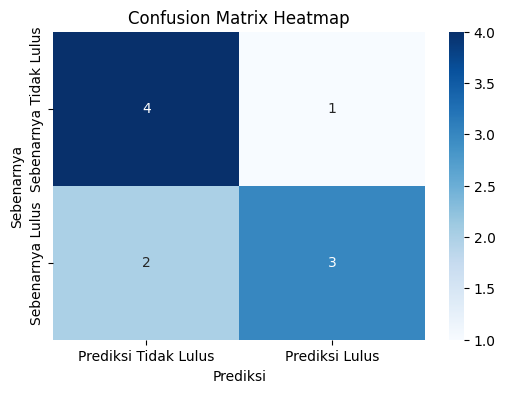

In [37]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prediksi Tidak Lulus", "Prediksi Lulus"],
            yticklabels=["Sebenarnya Tidak Lulus", "Sebenarnya Lulus"])
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Prediksi")
plt.ylabel("Sebenarnya")
plt.show()